In [ ]:
import os

# jax device and parallelization flags on m4 mac.
# modify as needed.
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils_corrected import Ntime, ACFs, set_detectors, set_detector_locations
from myutils_corrected import ln_likelihood_full_jit, Ntime, ACFs

from scipy.linalg import toeplitz, solve_triangular
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True)

/Users/kallol/Work/Misc/ringdown__2/examples/full-sky/../../src/myutils_corrected.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.rcParams["axes.grid"] = False

# Data download parameters

In [ ]:
# Event data downloaded using gwpy.
# Starting at t_ref = t_peak + 6tM as reported in LVK paper

tgps = 1420878141.235932 
tM = 0.337e-3 
tgps = tgps + 6*tM

seglen = 8
fs = 16384
fmin = 30
fmax       = 1500
event_id = "GW250114"
plot_checks = 0
T = 0.2
srate = 4096


# Only used to calculate the starting time of H1 to match the Fixed-sky case
# Can be avoided by calculating the starting from the whitened signal
ra = 2.33
dec = 0.190

factor = 10
seed       = 31567
t0         = 0.0

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l2/n2l2m2.dat"

In [5]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)

In [ ]:
n_analyze = Ntime(srate, T)

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
dL1_cond = bandpass_ds(dL1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)


nperseg = int(seglen * (1/(dH1.times.value[1] - dH1.times.value[0])))
noverlap = nperseg // 2

psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",    
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",     
)

In [ ]:

dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

# Prior limits
limits = [
    [55.0, 95.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [8]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_r, omega_i, omega_OT_r, omega_OT_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

rhoH, rhoL = ACFs(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
covH=toeplitz(rhoH)
covL=toeplitz(rhoL)
L_H=jnp.linalg.cholesky(covH)
L_L=jnp.linalg.cholesky(covL)

resp_H_py = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].response
resp_L_py = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].response
resp_H = jnp.asarray(resp_H_py, dtype=jnp.float64)
resp_L = jnp.asarray(resp_L_py, dtype=jnp.float64)

set_detectors(resp_H, resp_L)

H1 = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF]
L1 = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF]

rH = jnp.array([H1.location[0], H1.location[1], H1.location[2]], dtype=jnp.float64)
rL = jnp.array([L1.location[0], L1.location[1], L1.location[2]], dtype=jnp.float64)

set_detector_locations(rH, rL)

In [28]:
tH1, tL1

(1420878141.221026, 1420878141.2185555)

In [23]:
if tH1>tL1:
    print('H1 peak appears later')
else:
    print('L1 peak appears later')

H1 peak appears later


In [ ]:
# data strain starting from tH1 in both H1 and L1 for the Full-sky analysis
dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1, n_analyze)
dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tH1, n_analyze)

h_H_t = dH1_analysis_data[1]
h_L_t = dL1_analysis_data[1]

# jax numpyro sampling model

In [10]:
low  = jnp.asarray(low,  dtype=jnp.float64)   
high = jnp.asarray(high, dtype=jnp.float64)  


def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def model():
    theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
    numpyro.factor("loglike", loglik_fn(theta))

In [11]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns = NestedSampler(
    model,
    constructor_kwargs=dict(
        num_live_points=10000,     
        max_samples=500_000,      
        verbose=True,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,               
    ),
)
ns.run(rng_run)
ns.print_summary()
posterior = ns.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 298549
Efficiency: 0.032969530856226094
log(L) contour: -4287.712821681746
log(Z) est.: -769.5987538759234 +- 0.7828519893911048
log(Z | remaining) est.: 3527.7912514832833 +- 1.0248719855046462
ESS: 0.5911930528355376

-------
Num samples: 10008
Num likelihood evals: 649274
Efficiency: 0.019940266866441257
log(L) contour: -1457.9374998046435
log(Z) est.: -761.6429734766375 +- 0.8148554238782018
log(Z | remaining) est.: 705.225960037207 +- 0.9033963461395693
ESS: 0.5304891517178202



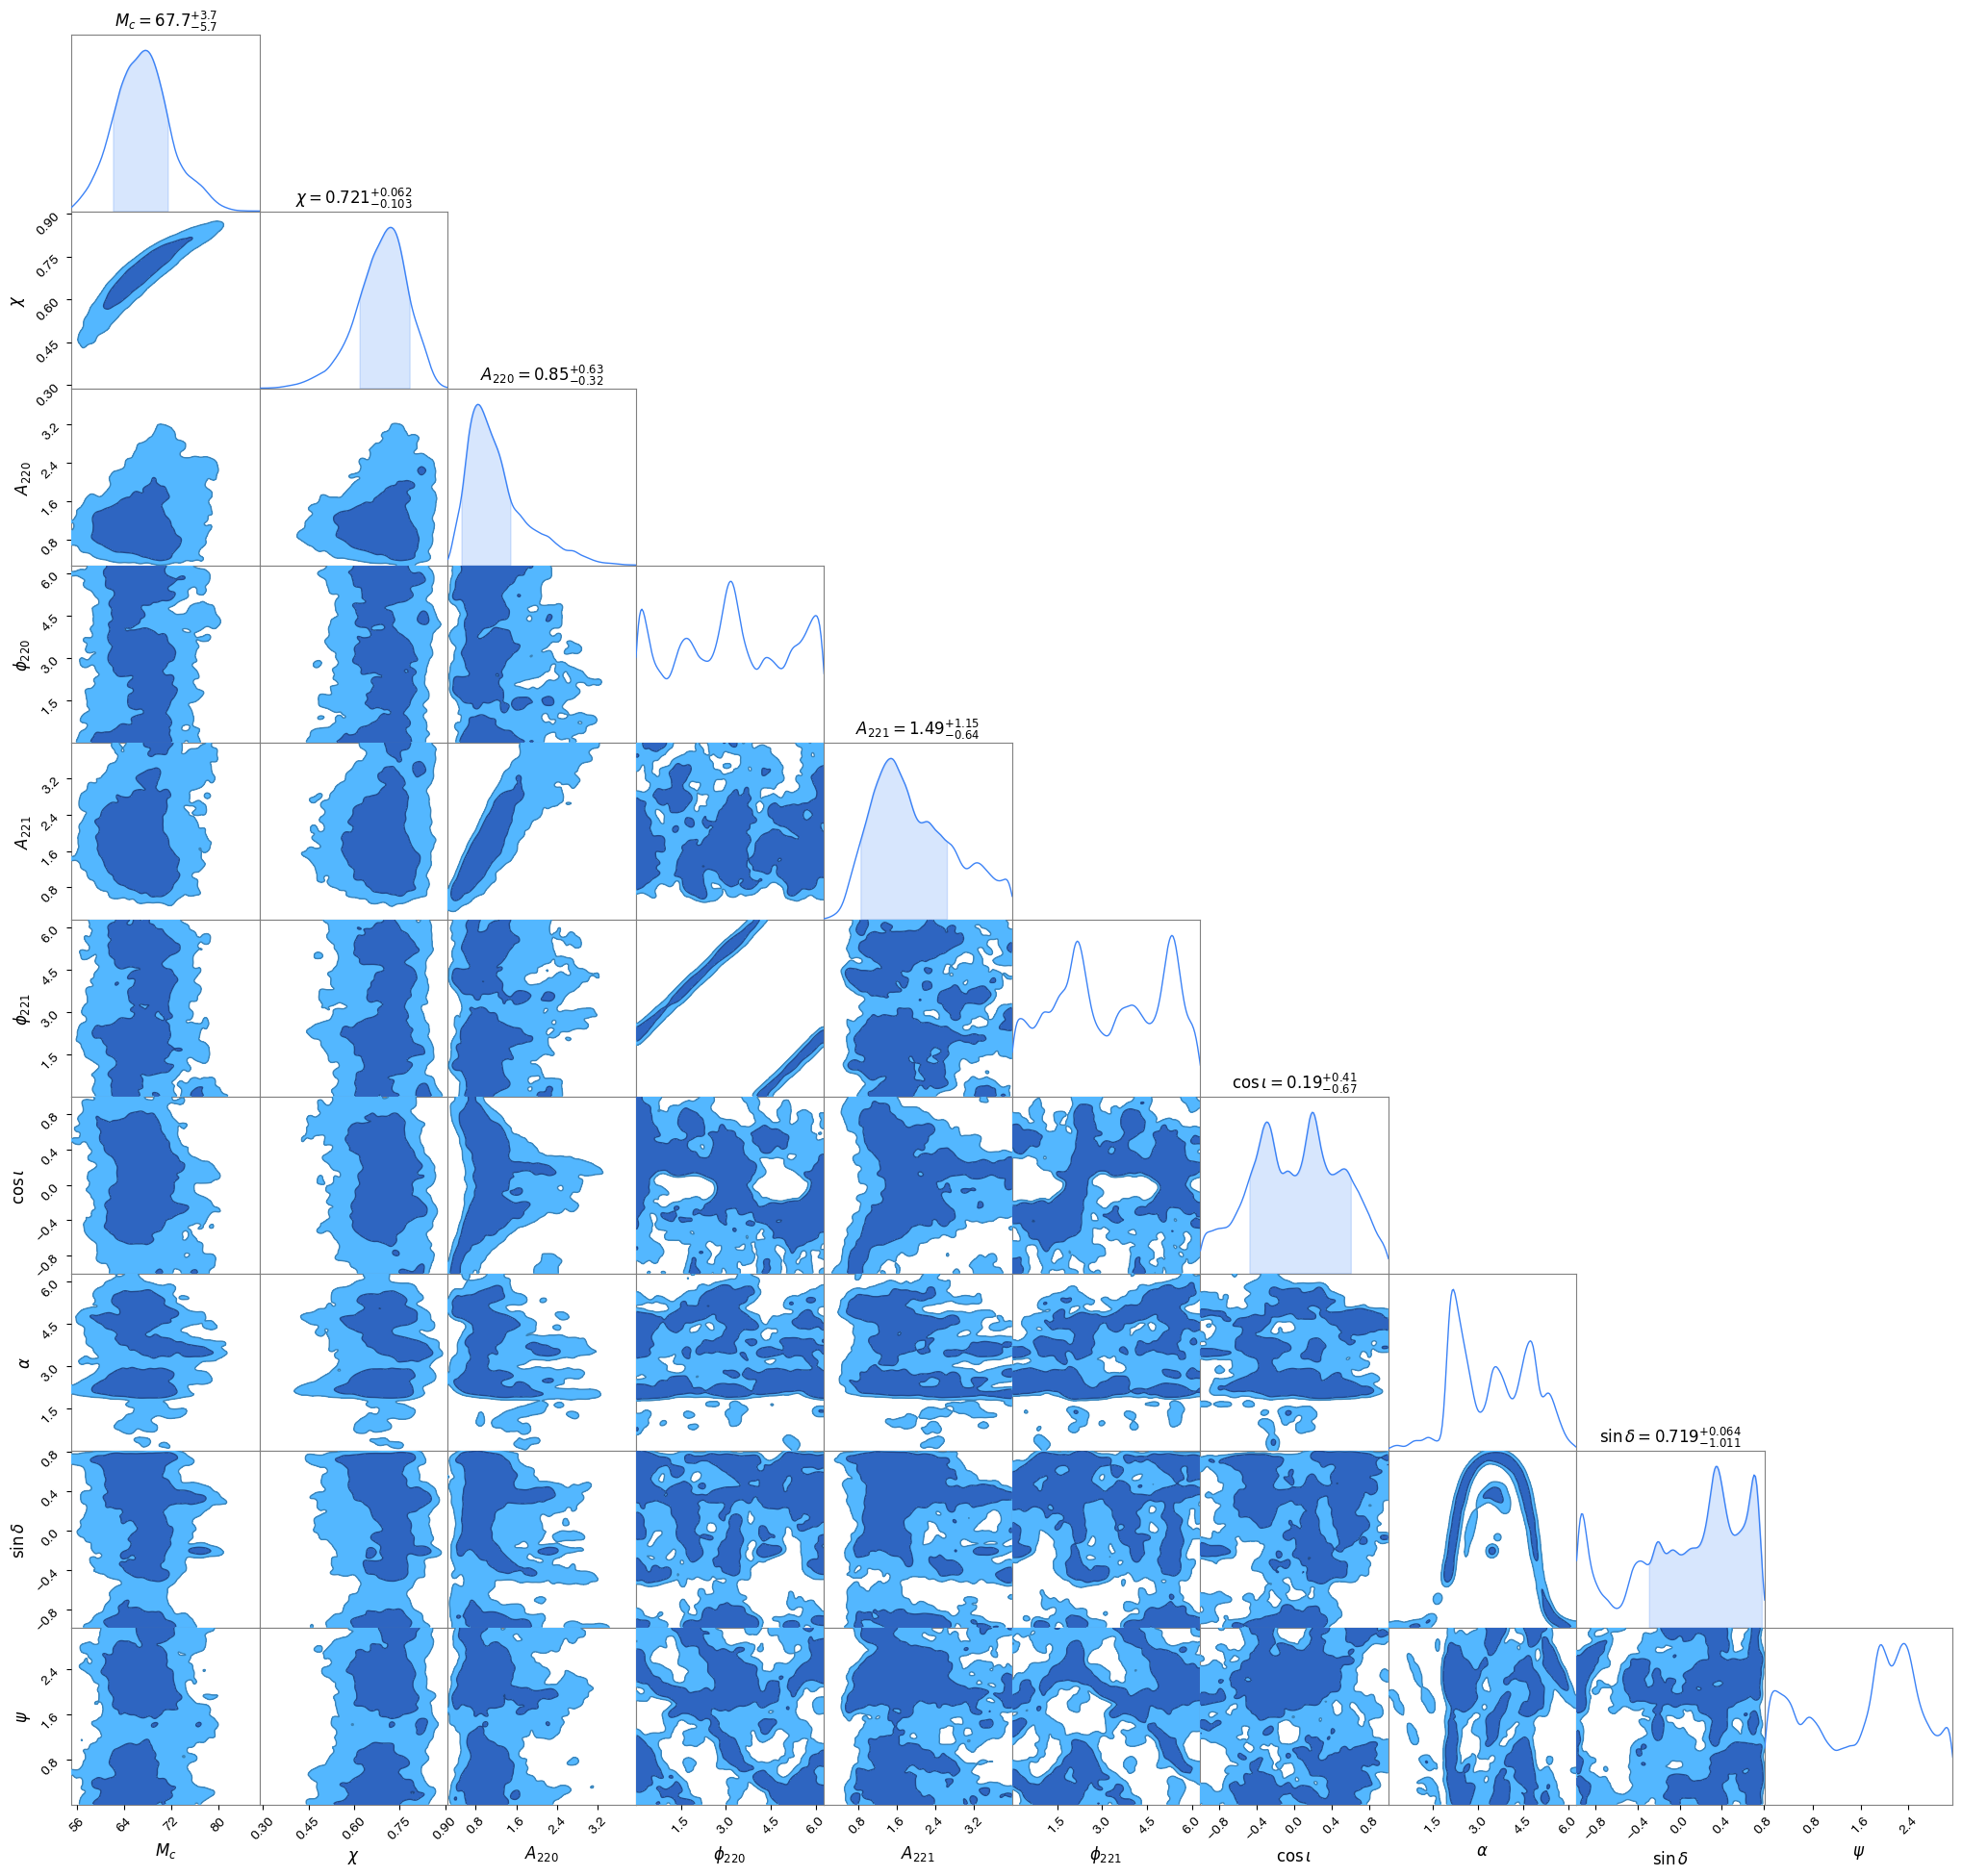

In [ ]:
ns_parameters = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\alpha$', r'$\sin \delta$', r'$\psi$']

df_ns = pd.DataFrame(posterior['theta'], columns=ns_parameters)
c = ChainConsumer()
c.add_chain(Chain(samples=df_ns, color='b', name="Full sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2]))
c.set_plot_config(
    PlotConfig(
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 30}
    )
)
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

In [13]:
onp.save('posterior.' + event_id + '.full-sky.npy', onp.asarray(posterior['theta']))

In [15]:
ns._results.log_Z_mean

Array(-738.52850492, dtype=float64)

In [24]:
tH1

1420878141.221026

In [25]:
tgps

LIGOTimeGPS(1420878141, 237954140)

In [26]:
tM

0.000337

In [16]:
limits = [
    [55.0, 95.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [17]:
low  = jnp.asarray(low,  dtype=jnp.float64)   
high = jnp.asarray(high, dtype=jnp.float64)  


def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def model_220():
    theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
    amp_phase_221 = jnp.array([0.0, 0.0])
    theta_ = jnp.concatenate(
                        [
                            theta[:4],
                            amp_phase_221,
                            theta[4:],
                        ],
                    )

    numpyro.factor("loglike", loglik_fn(theta_))

In [18]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_220 = NestedSampler(
    model_220,
    constructor_kwargs=dict(
        num_live_points=10000,     
        max_samples=500_000,      
        verbose=True,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,               
    ),
)
ns_220.run(rng_run)
ns_220.print_summary()
posterior_220 = ns_220.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 245387
Efficiency: 0.03996948772120404
log(L) contour: -2521.390630526116
log(Z) est.: -757.6935475556571 +- 0.6785427039000196
log(Z | remaining) est.: 1773.271289838131 +- 0.8670293759198371
ESS: 0.8550082072727982

-------
Num samples: 10008
Num likelihood evals: 537048
Efficiency: 0.024168542256310193
log(L) contour: -1140.5603620776787
log(Z) est.: -747.6059744262008 +- 0.8324979878948106
log(Z | remaining) est.: 400.8192980128689 +- 0.8630097207419466
ESS: 0.500094291549722

--

In [20]:
ns_220._results.log_Z_mean

Array(-744.16241249, dtype=float64)

In [19]:
ns_220._results.log_Z_mean

Array(-743.89893555, dtype=float64)

In [21]:
ns._results.log_Z_mean - ns_220._results.log_Z_mean

Array(5.22912241, dtype=float64)

In [20]:
ns._results.log_Z_mean - ns_220._results.log_Z_mean

Array(5.37043063, dtype=float64)